# Tree-Based Models: Full Engineered Feature Set

Identical to notebook 05 but using `shot_logs_cleaned_engineered.csv`, adding all features from notebook 02 that were absent in notebook 05: shot-type zone flags (`three_pointer`, `paint`, `mid_range`, `iso`), composite indices (`defender_distance_ratio`, `time_pressure_index`, `creation_load_log`), and `early_clock_indicator`. Baseline results to beat: Decision Tree AUC 0.629, Random Forest AUC 0.640, XGBoost AUC 0.642.

In [22]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: c:\Users\micha\Downloads\CS158\Shot-Value-Machine-Learning


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, log_loss,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
import xgboost as xgb

# load engineered feature set (produced in notebook 02)
df = pd.read_csv("data/processed/shot_logs_cleaned_engineered.csv")

In [24]:
# full feature set: all notebook 05 features + engineered additions from notebook 02
features = [
    # raw shot context (same as notebook 05)
    "shot_dist",
    "close_def_dist",
    "shot_clock",
    "dribbles",
    "touch_time",
    "pts_type",
    "period",
    # engineered: nonlinear and interaction terms (same as notebook 05)
    "game_clock_pct",
    "shot_clock_pct",
    "def_dist_x_shot_dist",
    "shot_dist_squared",
    # engineered: shot creation flags (same as notebook 05)
    "catch_and_shoot",
    "dribble_pull_up",
    # engineered: shot-type zone flags (new)
    "three_pointer",
    "paint",
    "mid_range",
    "pull_up",
    "iso",
    # engineered: composite indices
    "defender_distance_ratio",
    "time_pressure_index",
    "early_clock_indicator",
    "creation_load_log",
]

X = df[features].copy()
# encode location as binary: H=1, A=0
X["location"] = (df["location"] == "H").astype(int)
y = df["made"]

# 80/20 split — no scaling needed, tree models are scale-invariant
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (102205, 23)
X_test shape:  (25552, 23)


In [25]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_dt))
print("Log Loss:", log_loss(y_test, y_prob_dt))

=== Decision Tree ===
Accuracy: 0.6188165309956167
ROC AUC:  0.6315634605049483
Log Loss: 0.6536641869987159


In [26]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_rf))
print("Log Loss:", log_loss(y_test, y_prob_rf))

=== Random Forest ===
Accuracy: 0.6210472761427677
ROC AUC:  0.6391839306526609
Log Loss: 0.6488424466625815


In [27]:
# --- XGBoost ---
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC AUC: ", roc_auc_score(y_test, y_prob_xgb))
print("Log Loss:", log_loss(y_test, y_prob_xgb))

[0]	validation_0-logloss:0.68661
[50]	validation_0-logloss:0.65068
[100]	validation_0-logloss:0.64862
[150]	validation_0-logloss:0.64814
[200]	validation_0-logloss:0.64792
[250]	validation_0-logloss:0.64781
[299]	validation_0-logloss:0.64776

=== XGBoost ===
Accuracy: 0.6185425798371947
ROC AUC:  0.641405023834545
Log Loss: 0.6477552276320185


In [28]:
# four-way comparison: baseline models (notebooks 04/05) vs engineered versions (notebooks 06/07)
comparison = pd.DataFrame([
    # notebook 04 / 05 baselines (hardcoded from prior runs)
    {"Model": "LR — Baseline (nb04)",          "Accuracy": 0.6090, "ROC AUC": 0.6300, "Log Loss": 0.6570},
    {"Model": "Decision Tree — Baseline (nb05)", "Accuracy": 0.6163, "ROC AUC": 0.6293, "Log Loss": 0.6532},
    {"Model": "Random Forest — Baseline (nb05)", "Accuracy": 0.6200, "ROC AUC": 0.6397, "Log Loss": 0.6487},
    {"Model": "XGBoost — Baseline (nb05)",       "Accuracy": 0.6192, "ROC AUC": 0.6416, "Log Loss": 0.6474},
    # engineered versions (this notebook)
    {"Model": "Decision Tree — Engineered (nb07)", "Accuracy": accuracy_score(y_test, y_pred_dt),
                                                    "ROC AUC": roc_auc_score(y_test, y_prob_dt),
                                                    "Log Loss": log_loss(y_test, y_prob_dt)},
    {"Model": "Random Forest — Engineered (nb07)", "Accuracy": accuracy_score(y_test, y_pred_rf),
                                                    "ROC AUC": roc_auc_score(y_test, y_prob_rf),
                                                    "Log Loss": log_loss(y_test, y_prob_rf)},
    {"Model": "XGBoost — Engineered (nb07)",       "Accuracy": accuracy_score(y_test, y_pred_xgb),
                                                    "ROC AUC": roc_auc_score(y_test, y_prob_xgb),
                                                    "Log Loss": log_loss(y_test, y_prob_xgb)},
]).set_index("Model").round(4)

comparison

,Accuracy,ROC AUC,Log Loss
Model,,,
LR — Baseline (nb04),0.6090,0.6300,0.6570
Decision Tree — Baseline (nb05),0.6163,0.6293,0.6532
Random Forest — Baseline (nb05),0.6200,0.6397,0.6487
XGBoost — Baseline (nb05),0.6192,0.6416,0.6474
Decision Tree — Engineered (nb07),0.6188,0.6316,0.6537
Random Forest — Engineered (nb07),0.6210,0.6392,0.6488
XGBoost — Engineered (nb07),0.6185,0.6414,0.6478


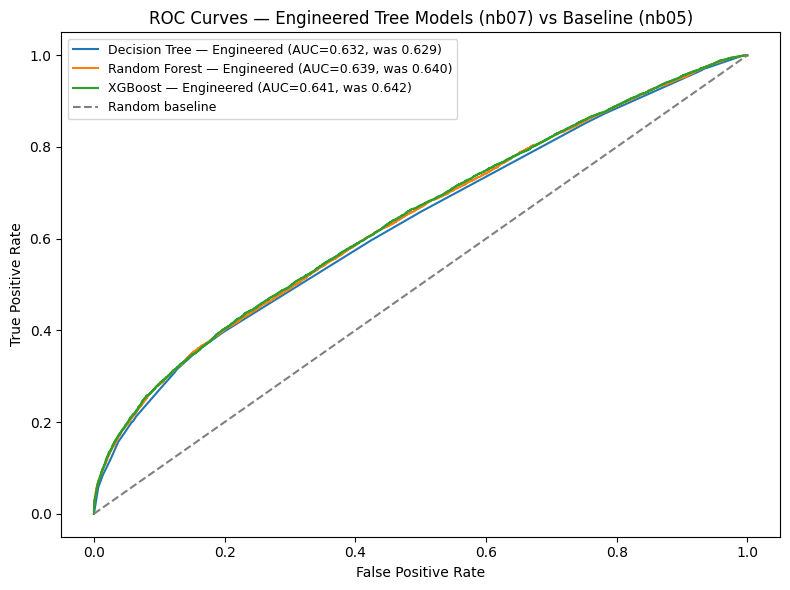

In [29]:
# ROC curves: engineered tree models overlaid, with notebook 05 AUC values annotated in legend
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, nb05_auc in [
    ("Decision Tree", y_prob_dt, 0.629),
    ("Random Forest", y_prob_rf, 0.640),
    ("XGBoost",       y_prob_xgb, 0.642),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    eng_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} — Engineered (AUC={eng_auc:.3f}, was {nb05_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Engineered Tree Models (nb07) vs Baseline (nb05)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

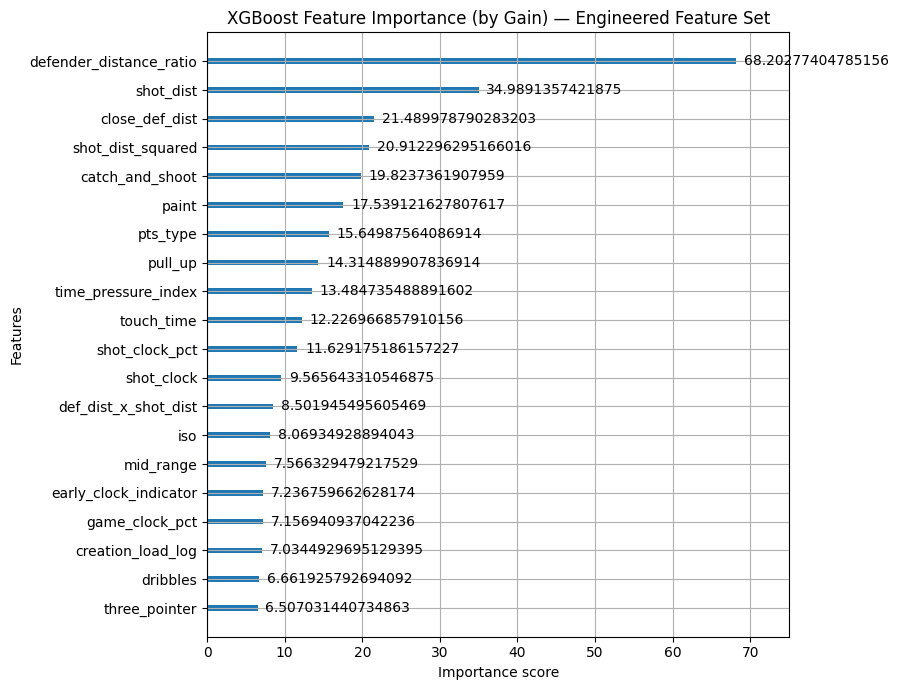

In [30]:
# XGBoost feature importance — shows which engineered features the model values most
fig, ax = plt.subplots(figsize=(9, 7))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=20, importance_type="gain")
ax.set_title("XGBoost Feature Importance (by Gain) — Engineered Feature Set")
plt.tight_layout()
plt.show()

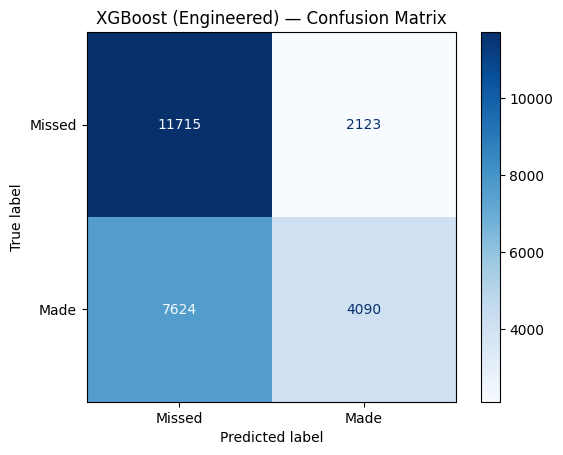

In [31]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Missed", "Made"]).plot(cmap="Blues")
plt.title("XGBoost (Engineered) — Confusion Matrix")
plt.show()

## Summary

Adding the full engineered feature set produced negligible gains across all three tree models. AUC changes were within ±0.002 of the notebook 05 baselines:

| Model | Baseline AUC (nb05) | Engineered AUC (nb07) | Delta |
|---|---|---|---|
| Decision Tree | 0.6293 | 0.6316 | +0.0023 |
| Random Forest | 0.6397 | 0.6392 | −0.0005 |
| XGBoost | 0.6416 | 0.6414 | −0.0002 |

The shot-type zone flags (`paint`, `mid_range`, `three_pointer`) and composite indices (`time_pressure_index`, `defender_distance_ratio`, `creation_load_log`) added no meaningful signal. This is likely because they are largely redundant with features the models already had such as `pts_type` and `shot_dist`.

The flat results across both feature sets confirm that the ceiling is not a feature engineering problem. The limiting factor is unmeasured shooter quality; who is taking the shot matters as much as the shot context itself, and that information is not the focus of this study.